In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
RISK_ORDER = ["Healthy", "Mild", "Moderate", "Severe"]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Data Preprocessing & Exploratory Data Analysis

### Load and inspect

In [161]:
df = pd.read_csv(r"sleep_health_dataset.csv")

In [162]:
df.shape

(100000, 32)

In [163]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [164]:
RISK_ORDER = ["Healthy", "Mild", "Moderate", "Severe"]

In [165]:
print(f"{'column name':30} {'# null':5}  {'dtype'}\n")
for col, typ in zip(df.columns.to_list()[:20], df.dtypes.to_list()[:20]):
    print(f"{col:30} {df[col].isna().sum():<6}  {str(typ)}")

column name                    # null  dtype

person_id                      0       int64
age                            0       int64
gender                         0       object
occupation                     0       object
bmi                            0       float64
country                        0       object
sleep_duration_hrs             0       float64
sleep_quality_score            0       float64
rem_percentage                 0       float64
deep_sleep_percentage          0       float64
sleep_latency_mins             0       int64
wake_episodes_per_night        0       int64
caffeine_mg_before_bed         0       int64
alcohol_units_before_bed       0       float64
screen_time_before_bed_mins    0       int64
exercise_day                   0       int64
steps_that_day                 0       int64
nap_duration_mins              0       int64
stress_score                   0       float64
work_hours_that_day            0       float64


In [166]:
print(f"{'column name':30} {'# null':5}  {'dtype'}\n")
for col, typ in zip(df.columns.to_list()[20:], df.dtypes.to_list()[20:]):
    print(f"{col:30} {df[col].isna().sum():<6}  {str(typ)}")

column name                    # null  dtype

chronotype                     0       object
mental_health_condition        0       object
heart_rate_resting_bpm         0       int64
sleep_aid_used                 0       int64
shift_work                     0       int64
room_temperature_celsius       0       float64
weekend_sleep_diff_hrs         0       float64
season                         0       object
day_type                       0       object
cognitive_performance_score    0       float64
sleep_disorder_risk            0       object
felt_rested                    0       int64


In [167]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.0,25000.75,50000.50,75000.25,100000.0
age,100000.0,34.706870,11.036373,18.0,26.00,33.00,42.00,69.0
bmi,100000.0,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0
sleep_duration_hrs,100000.0,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
rem_percentage,100000.0,20.243968,3.411354,10.0,18.00,20.30,22.60,30.0
deep_sleep_percentage,100000.0,20.253375,4.251096,5.0,17.40,20.30,23.20,30.0
sleep_latency_mins,100000.0,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
wake_episodes_per_night,100000.0,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
caffeine_mg_before_bed,100000.0,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0


### NaN Value check

In [168]:
len(df[df.isna().any(axis=1)])

0

### Feature / target split

In [169]:
X = df.drop(columns=["sleep_disorder_risk"])
y = df["sleep_disorder_risk"]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df["sleep_disorder_risk"])

### Train / test split

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=RANDOM_STATE, stratify=y
)

In [171]:
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (80000, 31)  Test shape: (20000, 31)


In [172]:
df_model = pd.concat([
    X_train,
    pd.Series(y_train, index=X_train.index, name="risk_level_ordinal")
], axis=1)

In [173]:
df_model.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,felt_rested,risk_level_ordinal
69597,69598,43,Female,Manager,20.7,India,5.87,3.8,18.4,21.8,15,3,0,0.0,51,0,2758,0,6.0,9.8,Morning,Anxiety,69,1,0,25.1,1.63,Autumn,Weekday,45.7,1,0
94218,94219,42,Male,Doctor,26.0,UK,7.14,5.1,19.3,18.2,31,2,0,0.0,136,0,10491,0,6.8,14.7,Neutral,Depression,68,1,0,22.5,0.45,Spring,Weekday,52.4,1,1
2820,2821,53,Male,Homemaker,27.4,Japan,6.32,5.6,20.6,12.0,18,2,0,1.0,49,0,3504,42,4.1,2.0,Neutral,Healthy,64,0,0,21.7,0.61,Winter,Weekday,63.8,0,0
5496,5497,36,Male,Homemaker,32.3,Brazil,8.23,4.8,20.3,20.0,14,6,0,0.0,12,0,8511,0,7.8,0.0,Neutral,Healthy,57,1,1,20.4,0.05,Autumn,Weekend,64.1,1,1
33621,33622,26,Male,Retired,19.9,Brazil,4.80,2.3,18.5,17.4,30,3,0,1.0,46,0,5757,47,4.9,0.1,Evening,Depression,64,0,0,15.0,2.00,Summer,Weekday,20.4,1,1


### Split column typing

In [174]:
cat_cols = [
    "gender",
    "occupation",
    "country",
    "chronotype",
    "mental_health_condition",
    "season",
    "day_type"
]

categorical_flags = [
    "exercise_day",
    "sleep_aid_used",
    "shift_work",
    "felt_rested"
]

target_col = ["sleep_disorder_risk"]

num_cols = [cols for cols in df.columns if cols not in cat_cols + categorical_flags + target_col]

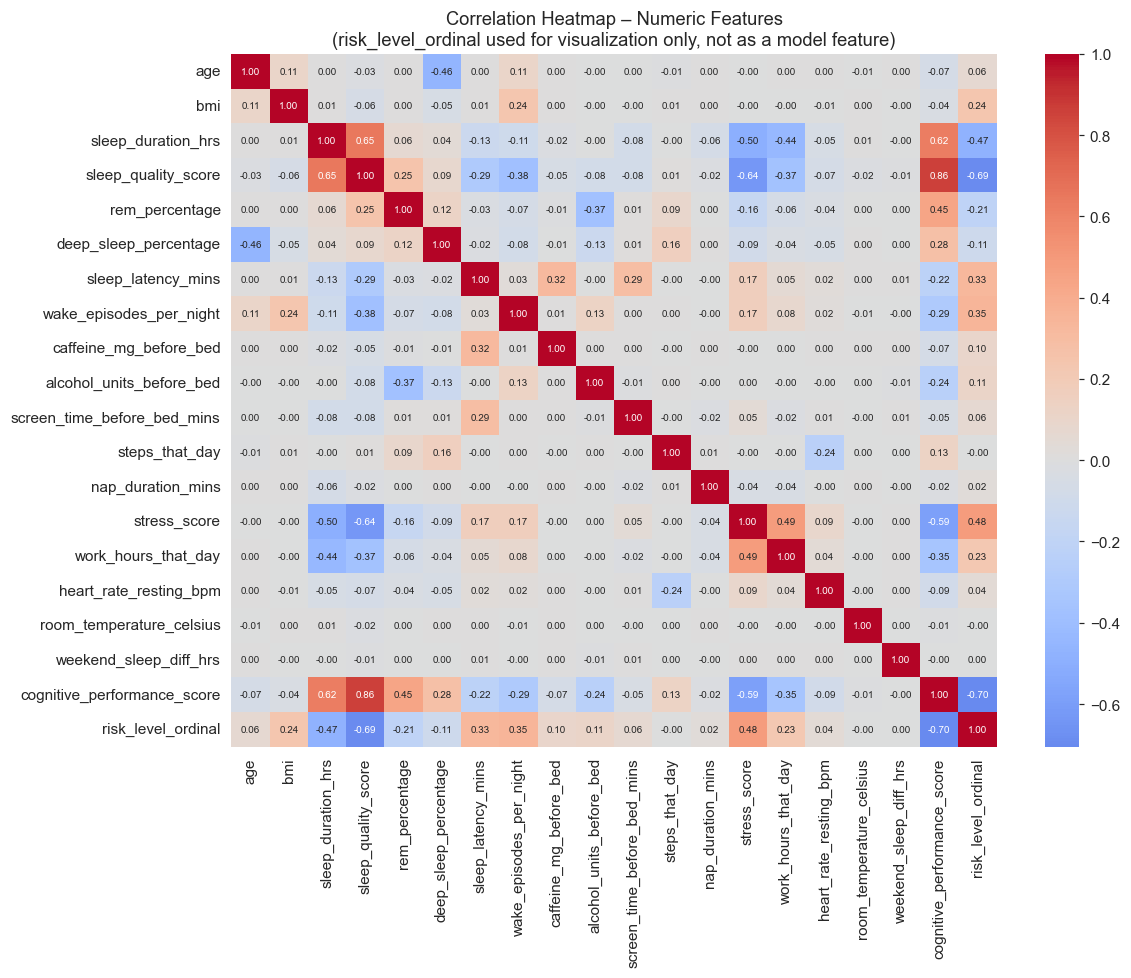

In [175]:
risk_map = {"Healthy": 0, "Mild": 1, "Moderate": 2, "Severe": 3}

corr_df = df_model[num_cols].drop(columns=["person_id"]).copy()

corr_df["risk_level_ordinal"] = df_model["risk_level_ordinal"]

corr = corr_df.corr()
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 6.5})

ax.set_title(
    "Correlation Heatmap – Numeric Features\n"
    "(risk_level_ordinal used for visualization only, not as a model feature)")

plt.tight_layout()
plt.show()

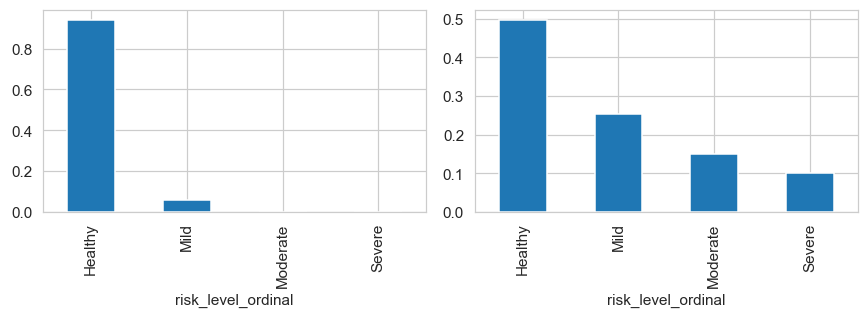

In [176]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

df_model.loc[df_model["sleep_quality_score"] >= 6.00, "risk_level_ordinal"].value_counts(normalize=True).plot(
    kind="bar", ax=ax[0]
)

df_model.loc[df_model["sleep_quality_score"] <= 3.80, "risk_level_ordinal"].value_counts(normalize=True).plot(
    kind="bar", ax=ax[1]
)
labels = ["Healthy", "Mild", "Moderate", "Severe"]

ax[0].set_xticks(range(4))
ax[0].set_xticklabels(labels)

ax[1].set_xticks(range(4))
ax[1].set_xticklabels(labels)
plt.tight_layout()
plt.show()

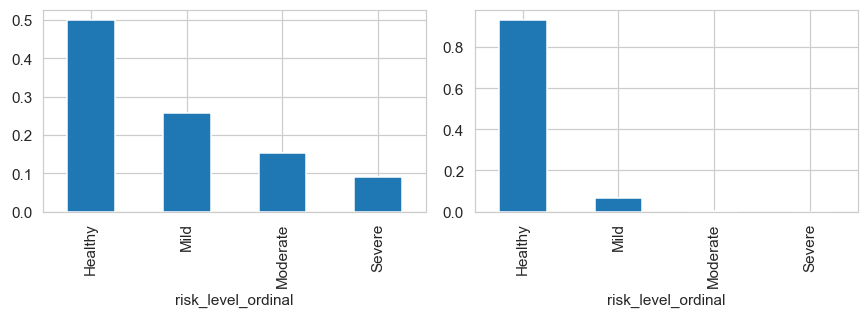

In [177]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

df_model.loc[df_model["cognitive_performance_score"] <= 44.20, "risk_level_ordinal"].value_counts(normalize=True).plot(
    kind="bar", ax=ax[0]
)

df_model.loc[df_model["cognitive_performance_score"] >= 75.80, "risk_level_ordinal"].value_counts(normalize=True).plot(
    kind="bar", ax=ax[1]
)

labels = ["Healthy", "Mild", "Moderate", "Severe"]

ax[0].set_xticks(range(4))
ax[0].set_xticklabels(labels)

ax[1].set_xticks(range(4))
ax[1].set_xticklabels(labels)
plt.tight_layout()
plt.show()

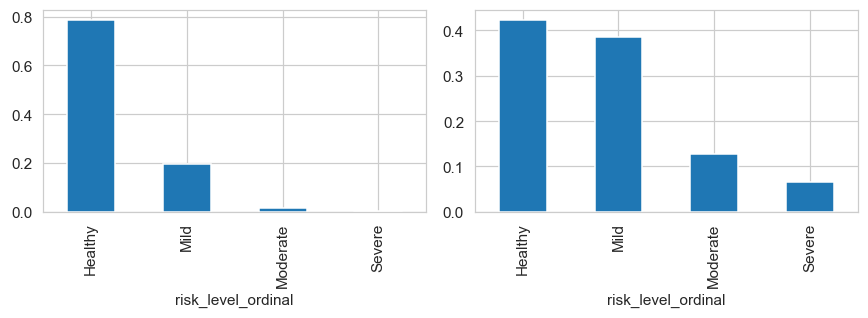

In [178]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

df_model.loc[df_model["felt_rested"] == 1, "risk_level_ordinal"].value_counts(normalize=True).plot(
    kind="bar", ax=ax[0]
)

df_model.loc[df_model["felt_rested"] == 0, "risk_level_ordinal"].value_counts(normalize=True).plot(
    kind="bar", ax=ax[1]
)

labels = ["Healthy", "Mild", "Moderate", "Severe"]

ax[0].set_xticks(range(4))
ax[0].set_xticklabels(labels)

ax[1].set_xticks(range(4))
ax[1].set_xticklabels(labels)
plt.tight_layout()
plt.show()

In [179]:
drop_cols = [
    "person_id",
    "cognitive_performance_score",
    "sleep_quality_score",
    "felt_rested"
]

num_cols = [cols for cols in df.columns if cols not in cat_cols + categorical_flags + drop_cols + target_col]

### Target distribution

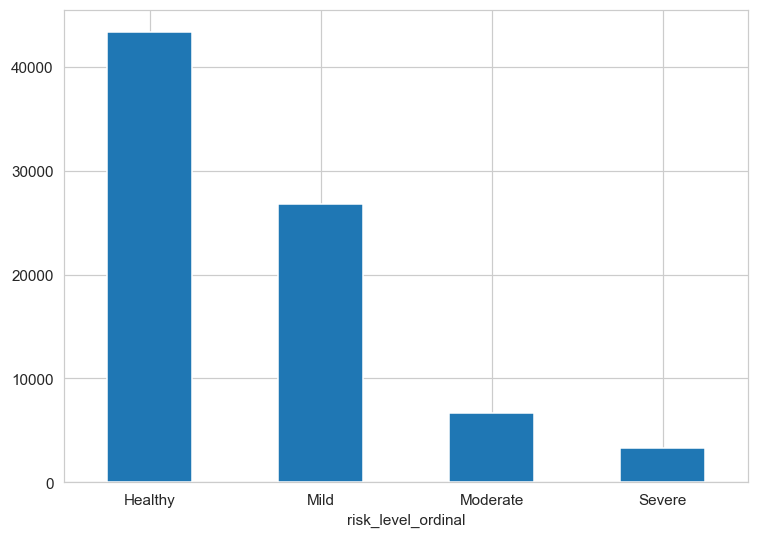

In [180]:
labels = ["Healthy", "Mild", "Moderate", "Severe"]

fig, ax = plt.subplots(figsize=(7, 5))

df_model["risk_level_ordinal"].value_counts().reindex([0, 1, 2, 3]).plot(
    kind="bar",
    ax=ax
)

ax.set_xticks(range(4))
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

In [181]:
print(target_encoder.classes_)

['Healthy' 'Mild' 'Moderate' 'Severe']


### Preprocessing pipeline

In [182]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("drop", "drop", drop_cols),
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols+categorical_flags)
])

In [183]:
df_model[num_cols].columns

Index(['age', 'bmi', 'sleep_duration_hrs', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'heart_rate_resting_bpm',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs'],
      dtype='object')

## Model Development

In [184]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=14, class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200, class_weight="balanced",random_state=RANDOM_STATE
    ),
}

In [185]:
cv_results = []

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", model)
    ])

    scores = cross_validate(
        X = X_train,
        y = y_train,
        estimator = pipe,
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_macro",
            "recall": "recall_macro",
            "f1": "f1_macro"
            },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("F1", ascending=False, inplace=True)

In [186]:
cv_results_df

,Model,Accuracy,Precision,Recall,F1
2,Hist Gradient Boosting,0.953637,0.875602,0.896536,0.884342
1,Random Forest,0.885288,0.811915,0.806499,0.808166
0,Logistic Regression,0.805913,0.702292,0.765263,0.727548


In [187]:
best_model_name = cv_results_df.loc[cv_results_df["F1"].idxmax(), "Model"]
best_model_name

'Hist Gradient Boosting'

In [188]:
hgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", models["Hist Gradient Boosting"])
])

In [189]:
param_grid = {
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_iter": [100, 200],
    "classifier__max_leaf_nodes": [15, 31]
}

In [190]:
grid_search = GridSearchCV(
    estimator = hgb_pipeline,
    param_grid = param_grid,
    scoring="f1_macro",
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=2
)

In [191]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_iter': [100, 200], 'classifier__max_leaf_nodes': [15, 31]}"
,scoring,'f1_macro'
,n_jobs,2
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('drop', ...), ('num', ...), ...]"


In [192]:
print(grid_search.best_score_)

0.8852407757606848


In [193]:
grid_search.best_params_

{'classifier__learning_rate': 0.1,
 'classifier__max_iter': 200,
 'classifier__max_leaf_nodes': 15}

In [194]:
final_pipeline = grid_search.best_estimator_

## Model Evaluation

In [195]:
y_pred = final_pipeline.predict(X_test)

In [207]:
tr_y_pred = final_pipeline.predict(X_train)
tr_results = {
    "predict": "train_set",
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_train, tr_y_pred),
    "Precision": precision_score(y_train, tr_y_pred, average="macro"),
    "Recall": recall_score(y_train, tr_y_pred, average="macro"),
    "F1": f1_score(y_train, tr_y_pred, average="macro")
    }

ts_y_pred = final_pipeline.predict(X_test)
ts_results = {
    "predict": "test_set",
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, ts_y_pred),
    "Precision": precision_score(y_test, ts_y_pred, average="macro"),
    "Recall": recall_score(y_test, ts_y_pred, average="macro"),
    "F1": f1_score(y_test, ts_y_pred, average="macro")
    }

In [213]:
bm_results_df = pd.concat([pd.DataFrame([tr_results]), pd.DataFrame([ts_results])], ignore_index=True)

In [214]:
bm_results_df

,predict,Model,Accuracy,Precision,Recall,F1
0,train_set,Hist Gradient Boosting,0.969313,0.916324,0.964490,0.937055
1,test_set,Hist Gradient Boosting,0.955000,0.872077,0.913257,0.890069


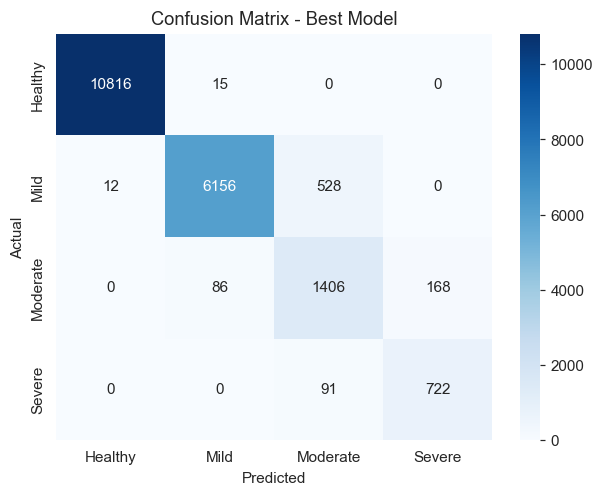

In [199]:
y_test_original = target_encoder.inverse_transform(y_test)
y_pred_original = target_encoder.inverse_transform(y_pred)

cm = confusion_matrix(
    y_test_original,
    y_pred_original,
    labels=RISK_ORDER
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=RISK_ORDER,
    yticklabels=RISK_ORDER
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Model")

plt.show()

In [200]:
cm_normalized = confusion_matrix(y_test_original, y_pred_original, labels=RISK_ORDER, normalize="true")
cm_normalized

array([[0.99861509, 0.00138491, 0.        , 0.        ],
       [0.00179211, 0.91935484, 0.07885305, 0.        ],
       [0.        , 0.05180723, 0.84698795, 0.10120482],
       [0.        , 0.        , 0.11193112, 0.88806888]])

In [201]:
report = classification_report(
    y_true=y_test,
    y_pred=y_pred,
    target_names=target_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     10831
        Mild       0.98      0.92      0.95      6696
    Moderate       0.69      0.85      0.76      1660
      Severe       0.81      0.89      0.85       813

    accuracy                           0.95     20000
   macro avg       0.87      0.91      0.89     20000
weighted avg       0.96      0.95      0.96     20000



In [216]:
import joblib

joblib.dump(final_pipeline, "final_model.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']